In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, auc, f1_score, matthews_corrcoef
from sklearn.model_selection import train_test_split

from rapidgbm import RapidGBMTuner

import glob
import mplhep as hep
hep.style.use([hep.style.ATLAS])
import pickle

import uproot
from iminuit import Minuit

In [3]:
iso_param_list = ['m_lx_ptcone20', 'm_lx_ptcone20_pt1000', 'm_lx_ptcone20_pt500', 'm_lx_ptcone30',
                  'm_lx_ptvarcone20', 'm_lx_ptvarcone30', 'm_lx_ptvarcone30_pt1000', 'm_lx_ptvarcone30_pt500',
                  'm_lx_topoetcone20', 'm_lx_topoetcone20ptCorrection', 'm_lx_topoetcone40', 'm_lx_neflowisol20']

iso_1_param_list = ['l1_ptcone20', 'l1_ptcone20_pt1000', 'l1_ptcone20_pt500', 'l1_ptcone30',
                    'l1_ptvarcone20', 'l1_ptvarcone30', 'l1_ptvarcone30_pt1000', 'l1_ptvarcone30_pt500',
                    'l1_topoetcone20', 'l1_topoetcone20ptCorrection', 'l1_topoetcone40', 'l1_neflowisol20']

iso_2_param_list = ['l2_ptcone20', 'l2_ptcone20_pt1000', 'l2_ptcone20_pt500', 'l2_ptcone30',
                    'l2_ptvarcone20', 'l2_ptvarcone30', 'l2_ptvarcone30_pt1000', 'l2_ptvarcone30_pt500',
                    'l2_topoetcone20', 'l2_topoetcone20ptCorrection', 'l2_topoetcone40', 'l2_neflowisol20']

pred_z_param_list = ['l1_iso_score', 'l2_iso_score', 
                     'l1_DNN_pel', 'l1_z0', 'l1_sig_z0', 'l2_DNN_pel', 'l2_z0', 'l2_sig_z0', 'EventInfo.actualIntPerXing',
                     'EventInfo.averageIntPerXing', 'EventInfo.mu', 'l1_DNN_pcf', 'l1_DNN_phf', 'l1_DNN_ple', 'l1_DNN_plh', 
                     'l1_DNN_ppc', 'l1_ECID', 'l1_charge', 'l2_DNN_pcf', 'l2_DNN_phf', 'l2_DNN_ple', 'l2_DNN_plh', 'l2_DNN_ppc',
                     'l2_ECID', 'l2_charge',]

others = ['EventInfo.eventNumber', 'truth_from_Z', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 
          'll_m', 'l1_truthType', 'l2_truthType', 'llg_m', 'EventInfo.channel', 'l1_truthOrigin', 'l2_truthOrigin'
        ]

others_data = ['EventInfo.eventNumber', 'EventInfo.cutflow', 'EventInfo.cutflow_new', 
          'll_m', 'llg_m', 'EventInfo.channel'
        ]

small_iso_param_list1 = iso_1_param_list[-4:]
small_iso_param_list2 = iso_2_param_list[-4:]

param_list = iso_1_param_list + iso_2_param_list + pred_z_param_list[2:] + others

In [4]:
# file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/monday_100k_zee/hist-sample.root'
# file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.10_11.57.47/hist-sample.root'
# file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.10_13.04.02/hist-sample.root'
# file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.10_13.26.19/hist-sample.root'
# file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.10_13.39.13/hist-sample.root'
file_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.10_14.57.01/hist-sample.root'
file = uproot.open(file_path)
print(file.keys())

data = file['HZG_Tree']
print(data.keys())

['EventLoop_OutputStream_MxAOD;1', 'truthTree;1', 'HZG_Tree;1', 'EventLoop_FileExecuted;1', 'EventLoop_JobStats;1', 'histo_cutflow;1', 'histo_cutflow_wt;1', 'histo_cutflow_ee;1', 'histo_cutflow_eey;1', 'histo_cutflow_mumu;1', 'histo_cutflow_mumuy;1', 'histo_cutflow_ee_wt;1', 'histo_cutflow_eey_wt;1', 'histo_cutflow_mumu_wt;1', 'histo_cutflow_mumuy_wt;1', 'histo_cutflow_tautau;1', 'histo_trigger_pass;1', 'histo_trigger_pass_wt;1', 'histo_trigger_pass_match;1', 'histo_trigger_pass_match_wt;1', 'histo_trigger_denom;1', 'histo_trigger_denom_wt;1', 'histo_trigSF;1', 'cutflow_601189;1', 'cutflow_601189_w;1', 'cutflow_601189_w2;1', 'cutflow_601189_SOW;1', 'cutflow_601189_w_SOW;1', 'cutflow_601189_w2_SOW;1', 'TriggerEfficienciesPassed;1', 'TriggerEfficienciesMatched;1', 'EventLoop_RunTime;1', 'EventLoop_EventCount;1']
['Btag60_N_j', 'Btag70_N_j', 'Btag77_N_j', 'Btag85_N_j', 'Btag_N_j', 'Central_N_j', 'Central_pT_jj', 'EventInfo.PVx', 'EventInfo.PVy', 'EventInfo.PVz', 'EventInfo.actualIntPerXin

In [5]:
data = pd.DataFrame(data.arrays(library='pd'))

In [6]:
print(data.columns)

Index(['Btag60_N_j', 'Btag70_N_j', 'Btag77_N_j', 'Btag85_N_j', 'Btag_N_j',
       'Central_N_j', 'Central_pT_jj', 'EventInfo.PVx', 'EventInfo.PVy',
       'EventInfo.PVz',
       ...
       'phForElectron2_passiso_FixedCutTightCaloOnly', 'ph_isMedium',
       'ph_isTight', 'ph_istruth', 'ph_istruth2', 'ph_passiso_FixedCutLoose',
       'ph_passiso_FixedCutTight', 'ph_passiso_FixedCutTightCaloOnly',
       'trigger_passed', 'EventInfo.eventNumber'],
      dtype='object', length=458)


In [7]:
for col in data.columns:
    if 'truth' in col:
        print(col, data[col].dtype)

Z_truth_mass float32
l1_eta_truth float32
l1_phi_truth float32
l1_pt_truth float32
l1_truthOrigin float32
l1_truthPdgId float32
l1_truthType float32
l2_eta_truth float32
l2_phi_truth float32
l2_pt_truth float32
l2_truthOrigin float32
l2_truthPdgId float32
l2_truthType float32
Al1_istruth int32
Al2_istruth int32
channel_truth int32
index_l1_truth int32
index_l2_truth int32
index_llg_truth int32
l1_barcode_truth int32
l1_pid_truth int32
l2_barcode_truth int32
l2_pid_truth int32
n_llg_truth int32
truthChannel int32
truthPhoton int32
l1_istruth bool
l1_istruth2 bool
l1_istruth_2 bool
l2_istruth bool
l2_istruth2 bool
l2_istruth_2 bool
ph_istruth bool
ph_istruth2 bool


In [8]:
((data['l1_truthOrigin'] == 13 ) & ( data['l2_truthOrigin'] == 13 ))

(((data['l1_truthPdgId'] == 11) & (data['l2_truthPdgId'] == -11))
| ((data['l1_truthPdgId'] == -11) & (data['l2_truthPdgId'] == 11)))

0        True
1       False
2        True
3        True
4        True
        ...  
5262    False
5263     True
5264     True
5265    False
5266    False
Length: 5267, dtype: bool

In [9]:

data = data[data['EventInfo.channel'] == 1]

isZ_bool = ((data['l1_truthOrigin'] == 13 ) & ( data['l2_truthOrigin'] == 13 )) & (
    (((data['l1_truthPdgId'] == 11) & (data['l2_truthPdgId'] == -11)) | ((data['l1_truthPdgId'] == -11) & (data['l2_truthPdgId'] == 11)))
    & (data['EventInfo.channel'] == 1)
    | (data['EventInfo.channel'] == 2) &
    (data['l1_charge'] + data['l2_charge'] == 0)
)
print(data[data['EventInfo.channel'] == 2][['l1_truthPdgId', 'l2_truthPdgId']].value_counts())
print(isZ_bool.shape)

Series([], Name: count, dtype: int64)
(5263,)


In [10]:
print(data[isZ_bool]['EventInfo.channel'].value_counts())

EventInfo.channel
1    3702
Name: count, dtype: int64


In [11]:
print(len(data[isZ_bool & (data['EventInfo.cutflow'] < 14)]))
print(np.sum(isZ_bool))

ATLAS_Z = len(data[isZ_bool & (data['EventInfo.cutflow'] >= 14)])
true_Z = len(data[isZ_bool])

possible_improvement = true_Z - ATLAS_Z

print(possible_improvement)

print(possible_improvement/ATLAS_Z)

880
3702
880
0.3118355776045358


Text(1, 0, 'll_m')

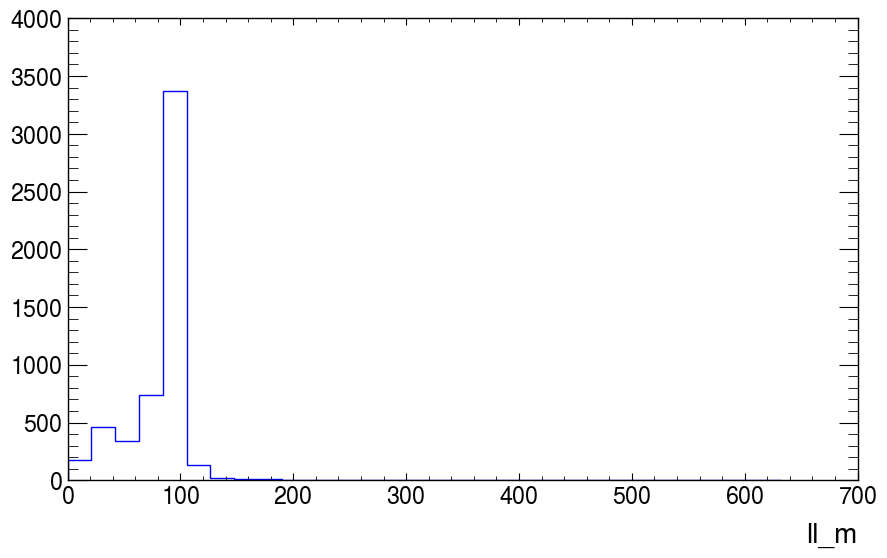

In [12]:
param = 'll_m'
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data[param], bins=30, histtype='step', color='b', label=param)
ax.set_xlabel(param)



In [13]:
print(data['EventInfo.channel_ZH'].value_counts())

EventInfo.channel_ZH
0    5191
1      72
Name: count, dtype: int64


In [14]:
for col in data.columns:
    if 'ZH' in col:
        print(col, data[col].dtype)
    # print(col, data[col].dtype)

l1_eta_ZH float32
l1_eta_Zmassconstraint_ZH float32
l1_mass_ZH float32
l1_mass_Zmassconstraint_ZH float32
l1_phi_ZH float32
l1_phi_Zmassconstraint_ZH float32
l1_pt_ZH float32
l1_pt_Zmassconstraint_ZH float32
l2_eta_ZH float32
l2_eta_Zmassconstraint_ZH float32
l2_mass_ZH float32
l2_mass_Zmassconstraint_ZH float32
l2_phi_ZH float32
l2_phi_Zmassconstraint_ZH float32
l2_pt_ZH float32
l2_pt_Zmassconstraint_ZH float32
ll_dm_mll_mZ_ZH float32
ll_dm_mll_mZ_Zmassconstraint_ZH float32
ll_eta_ZH float32
ll_eta_Zmassconstraint_ZH float32
ll_m_ZH float32
ll_m_Zmassconstraint_ZH float32
ll_phi_ZH float32
ll_phi_Zmassconstraint_ZH float32
ll_pt_ZH float32
ll_pt_Zmassconstraint_ZH float32
EventInfo.channel_ZH int32


In [15]:
print(data['l1_eta_ZH'][data['EventInfo.channel_ZH'] == 1].shape)
print(data['l1_eta'][data['EventInfo.channel'] == 1].shape)

(72,)
(5263,)


In [16]:
print(data['EventInfo.cutflow_new'].value_counts())
print(data['EventInfo.cutflow_new'][data['l1_eta_ZH'] != 0.0].value_counts())
print(data['EventInfo.cutflow_new'][data['l1_eta_ZH'] == 0.0].value_counts())

EventInfo.cutflow_new
0     2891
16    2057
15     199
17      83
18      13
19       8
23       6
20       3
21       3
Name: count, dtype: int64
EventInfo.cutflow_new
16    56
15    13
17     3
Name: count, dtype: int64
EventInfo.cutflow_new
0     2891
16    2001
15     186
17      80
18      13
19       8
23       6
20       3
21       3
Name: count, dtype: int64


no


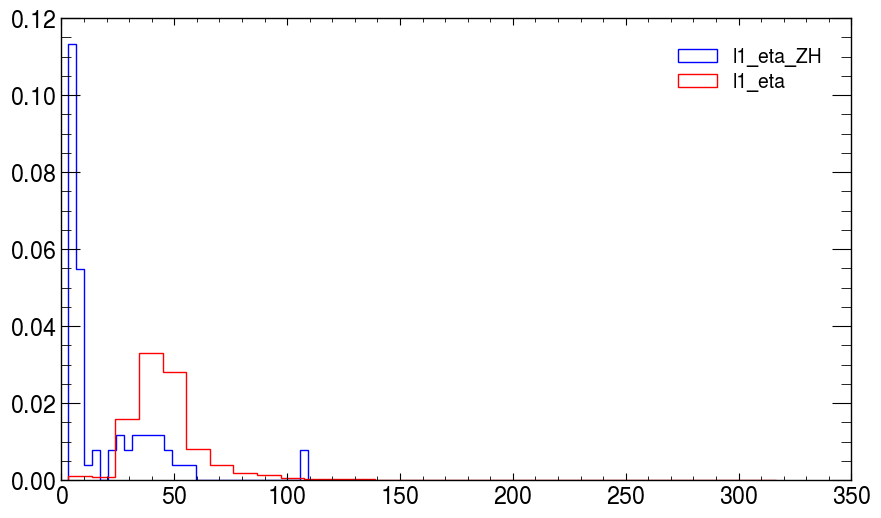

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(data['l1_pt_ZH'][data['EventInfo.channel_ZH'] == 1], bins=30, histtype='step', color='b', label='l1_eta_ZH', density=True)
ax.hist(data['l1_pt'][data['EventInfo.channel'] == 1], bins=30, histtype='step', color='r', label='l1_eta', density=True)
ax.legend()
print('no')

In [18]:
charge_mask = (data['l1_charge'] == data['l2_charge'])
print(charge_mask.value_counts())
print(charge_mask.value_counts(normalize=True))
print(charge_mask[isZ_bool].value_counts())
print(charge_mask[isZ_bool].value_counts(normalize=True))

False    4948
True      315
Name: count, dtype: int64
False    0.940148
True     0.059852
Name: proportion, dtype: float64
False    3689
True       13
Name: count, dtype: int64
False    0.996488
True     0.003512
Name: proportion, dtype: float64


In [20]:
true_data_1_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.11_10.59.56/hist-sample.root'
true_data_2_path = '/groups/hep/kinch/ATLAS_framework/MyAnalysis/run/Run/H2ZyAnalysis_2024.12.11_11.00.56/hist-sample.root'

true_data_1 = uproot.open(true_data_1_path)
true_data_2 = uproot.open(true_data_2_path)

print(true_data_1.keys())
print(true_data_2.keys())

# true_data_1 = pd.DataFrame(true_data_1['HZG_Tree'].arrays(library='pd'))
# true_data_2 = pd.DataFrame(true_data_2['HZG_Tree'].arrays(library='pd'))

['HZG_Tree;5', 'HZG_Tree;4', 'EventLoop_OutputStream_MxAOD;1', 'truthTree;1', 'EventLoop_FileExecuted;1', 'EventLoop_JobStats;1', 'histo_cutflow;1', 'histo_cutflow_wt;1', 'histo_cutflow_ee;1', 'histo_cutflow_eey;1', 'histo_cutflow_mumu;1', 'histo_cutflow_mumuy;1', 'histo_cutflow_ee_wt;1', 'histo_cutflow_eey_wt;1', 'histo_cutflow_mumu_wt;1', 'histo_cutflow_mumuy_wt;1', 'histo_cutflow_tautau;1', 'histo_trigger_pass;1', 'histo_trigger_pass_wt;1', 'histo_trigger_pass_match;1', 'histo_trigger_pass_match_wt;1', 'histo_trigger_denom;1', 'histo_trigger_denom_wt;1', 'histo_trigSF;1', 'cutflow_428776;1', 'cutflow_428776_w;1', 'cutflow_428776_w2;1', 'cutflow_428776_SOW;1', 'cutflow_428776_w_SOW;1', 'cutflow_428776_w2_SOW;1', 'cutflow_431885;1', 'cutflow_431885_w;1', 'cutflow_431885_w2;1', 'cutflow_431885_SOW;1', 'cutflow_431885_w_SOW;1', 'cutflow_431885_w2_SOW;1', 'cutflow_435816;1', 'cutflow_435816_w;1', 'cutflow_435816_w2;1', 'cutflow_435816_SOW;1', 'cutflow_435816_w_SOW;1', 'cutflow_435816_w2_

In [36]:
data22_path = '/groups/hep/kinch/data/Data/data22_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp22_v01_p6029'
data23_path = '/groups/hep/kinch/data/Data/data23_13p6TeV.periodAllYear.physics_Main.PhysCont.DAOD_PHYS.grp23_v01_p6029'

data22_files = glob.glob(data22_path + '/*.1')
data23_files = glob.glob(data23_path + '/*.1')

data22_test = uproot.open(data22_files[0])
data23_test = uproot.open(data23_files[0])

print(data22_test.keys())
print(data23_test.keys())

# data22_test = pd.DataFrame(data22_test['CollectionTree'].arrays(library='pd'))
# data23_test = pd.DataFrame(data23_test['CollectionTree'].arrays(library='pd'))

data22_test = data22_test['CollectionTree']
data23_test = data23_test['CollectionTree']

print(data22_test.keys())
print(data23_test.keys())

eventnumber22 = data22_test['EventInfoAuxDyn.eventNumber'].array()
eventnumber23 = data23_test['EventInfoAuxDyn.eventNumber'].array()

for key in data22_test.keys():
    if 'Number' in key:
        print(key)

['##Params;3', '##Params;2', '##Shapes;3', '##Shapes;2', '##Links;3', '##Links;2', 'MetaData;1', 'MetaDataHdr;1', 'MetaDataHdrForm;1', 'CollectionTree;1', 'POOLContainer;1', 'POOLContainerForm;1', 'POOLCollectionTree;1']
['##Params;3', '##Params;2', '##Shapes;3', '##Shapes;2', '##Links;3', '##Links;2', 'MetaData;1', 'MetaDataHdr;1', 'MetaDataHdrForm;1', 'CollectionTree;1', 'POOLContainer;1', 'POOLContainerForm;1', 'POOLCollectionTree;1']
['xTrigDecisionAux.', 'METAssoc_AntiKt4EMPFlowAux.', 'METAssoc_AntiKt4EMTopoAux.', 'EventInfoAux.', 'Kt4EMPFlowEventShapeAux.', 'Kt4EMPFlowNeutEventShapeAux.', 'Kt4EMPFlowPUSBEventShapeAux.', 'Kt4EMTopoOriginEventShapeAux.', 'NeutralParticleFlowIsoCentralEventShapeAux.', 'NeutralParticleFlowIsoForwardEventShapeAux.', 'TopoClusterIsoCentralEventShapeAux.', 'TopoClusterIsoForwardEventShapeAux.', 'BTagging_AntiKt4EMPFlowAux.', 'BTagging_AntiKtVR30Rmax4Rmin02TrackAux.', 'CombinedMuonTrackParticlesAux.', 'DiTauJetsAux.', 'DiTauJetsLowPtAux.', 'ElectronsAux.

In [37]:
for key in true_data_1['HZG_Tree'].keys():
    if 'Number' in key:
        print(key)

EventInfo.runNumber
mc_channelNumber
EventInfo.eventNumber


In [34]:
eventNumber_datafile = true_data_1['HZG_Tree']['EventInfo.eventNumber'].array()
print(len(eventNumber_datafile))

335916


In [32]:
# check to see if the datafile comes from data22 or data23
print(np.sum(np.isin(eventNumber_datafile, eventnumber22)))
print(np.sum(np.isin(eventNumber_datafile, eventnumber23)))

56155
36


In [38]:
# test EventInfoAuxDyn.runNumber

runNumber22 = data22_test['EventInfoAuxDyn.runNumber'].array()
runNumber23 = data23_test['EventInfoAuxDyn.runNumber'].array()

runNumber_datafile = true_data_1['HZG_Tree']['EventInfo.runNumber'].array()


In [40]:
print(np.sum(np.isin(runNumber_datafile, runNumber22)))
print(np.sum(np.isin(runNumber_datafile, runNumber23)))
print(len(runNumber22))

56155
0
228085
